# Lab 5 : Exploratory Data Analysis



---



## Use Huggingface to download the dataset 🤗. (The alternative way is below if you want)

In [ ]:
%pip install -U huggingface_hub

In [ ]:
!hf download celesca/election_results_2569 --repo-type dataset --local-dir ./

C:\Users\lchan\OneDrive\Desktop\KMUTT\Y2T2\CPE232\Week5\Lab-HW



Fetching 4 files: 100%|██████████| 4/4 [00:04<00:00,  1.02s/it]


In [ ]:
!unzip -q ./data.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


### **Or you can download the dataset from this Google Drive and mount a drive**

: https://drive.google.com/drive/folders/1sD5YC3yke9ZbEEy84ruLpKgY3_0sYgIu



---



## Thai Font in Matplotlib

Download Thai font: https://drive.google.com/drive/folders/1s_xqY9Wyx9QNNPZkZlTbFlNM5-zQc4iQ?usp=drive_link

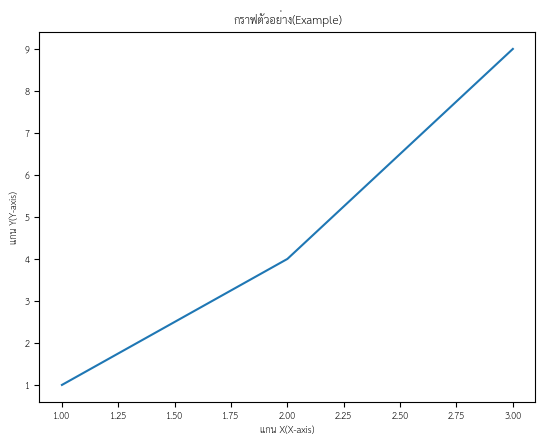

In [1]:
#Test Thai Font
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

font_path = 'THSarabunNew.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'TH Sarabun New'

plt.title('กราฟตัวอย่าง(Example)')
plt.plot([1,2,3],[1,4,9])
plt.xlabel('แกน X(X-axis)')
plt.ylabel('แกน Y(Y-axis)')
plt.show()

If output's graph have these example texts "**กราฟตัวอย่าง(Example)**", "**แกน X(X-axis)**", and "**แกน Y(Y-axis)**", Then it's work.



---


## Read example data

In [2]:
import pandas as pd

winnerdf = pd.read_csv("winner/winner.csv")
winnerdf.head()

,id,name,provinceId,partyWinner,number,provinceName,candidates,provinceId_key
0,26b4aad6-94b3-490a-9390-71636d5e97a4,กรุงเทพมหานคร เขต 1,10,1,1,กรุงเทพมหานคร,"[{'fullName': 'ปารเมศ วิทยารักษ์สรรค์', 'total...",10
1,a4b95b52-2371-4a3e-bc51-6b3381578720,กรุงเทพมหานคร เขต 2,10,1,2,กรุงเทพมหานคร,"[{'fullName': 'เสกสิทธิ์ แย้มสงวนศักดิ์', 'tot...",10
2,be7ff60c-305b-47b8-a8b6-dd699e5f5d6c,กรุงเทพมหานคร เขต 3,10,1,3,กรุงเทพมหานคร,"[{'fullName': 'จรยุทธ จตุรพรประสิทธิ์', 'total...",10
3,8d1c14af-dbec-46bd-ba6d-b605490e385a,กรุงเทพมหานคร เขต 4,10,1,4,กรุงเทพมหานคร,"[{'fullName': 'ภัณฑิล น่วมเจิม', 'totalVotes':...",10
4,380c6e8c-51e2-4acc-8e3f-7772bdf18ae8,กรุงเทพมหานคร เขต 5,10,1,5,กรุงเทพมหานคร,"[{'fullName': 'ปิติกรณ์ บรรณเภสัช', 'totalVote...",10


## JSON-parser

If you have the data like this :     

```
[{'fullName': 'ปารเมศ วิทยารักษ์สรรค์', 'totalVotes': 32564, 'candidateNumber': 5, 'updatedAt': '2026-02-07T16:49:10.564Z', 'percent': 44.39, 'rank': 1, 'party': {'code': '46', 'color': '#ff6412', 'name': 'พรรคประชาชน'}}, {'fullName': 'พีรวุฒิ พิมพ์สมฤดี', 'totalVotes': 14018, 'candidateNumber': 9, 'updatedAt': '2026-02-07T16:49:14.267Z', 'percent': 19.11, 'rank': 2, 'party': {'code': '27', 'color': '#70c0fd', 'name': 'พรรคประชาธิปัตย์'}}, {'fullName': 'ลลิดา เพริศวิวัฒนา', 'totalVotes': 13661, 'candidateNumber': 1, 'updatedAt': '2026-02-07T16:49:03.079Z', 'percent': 18.62, 'rank': 3, 'party': {'code': '37', 'color': '#131c5f', 'name': 'พรรคภูมิใจไทย'}}]
```

Hint: use below code to transform to python list instead of string

```
import ast

for i in winner_df['candidates']:
    
    obj = ast.literal_eval(i)

    for candidate in obj:
        print(candidate)
```



---




In [3]:
province_fix_map = {
    'กรงเทพมหานคร': 'กรุงเทพมหานคร',
    'กระบ': 'กระบี่',
    'กาญจนบร': 'กาญจนบุรี',
    'กาฬสนธ': 'กาฬสินธุ์',
    'กำแพงเพชร': 'กำแพงเพชร',
    'ขอนแกน': 'ขอนแก่น',
    'จนทบร': 'จันทบุรี',
    'ฉะเชงเทรา': 'ฉะเชิงเทรา',
    'ชมพร': 'ชุมพร',
    'ชยนาท': 'ชัยนาท',
    'ชยภม': 'ชัยภูมิ',
    'ชลบร': 'ชลบุรี',
    'ตรง': 'ตรัง',
    'ตราด': 'ตราด',
    'ตาก': 'ตาก',
    'นครนายก': 'นครนายก',
    'นครปฐม': 'นครปฐม',
    'นครพนม': 'นครพนม',
    'นครราชสมา': 'นครราชสีมา',
    'นครศรธรรมราช': 'นครศรีธรรมราช',
    'นครสวรรค': 'นครสวรรค์',
    'นนทบร': 'นนทบุรี',
    'นราธวาส': 'นราธิวาส',
    'นาน': 'น่าน',
    'บงกาฬ': 'บึงกาฬ',
    'บรรมย': 'บุรีรัมย์',
    'ปตตาน': 'ปัตตานี',
    'ปทมธาน': 'ปทุมธานี',
    'ประจวบครขนธ': 'ประจวบคีรีขันธ์',
    'ปราจนบร': 'ปราจีนบุรี',
    'พงงา': 'พังงา',
    'พจตร': 'พิจิตร',
    'พทลง': 'พัทลุง',
    'พระนครศรอยธยา': 'พระนครศรีอยุธยา',
    'พษณโลก': 'พิษณุโลก',
    'พะเยา': 'พะเยา',
    'ภเกต': 'ภูเก็ต',
    'มกดาหาร': 'มุกดาหาร',
    'มหาสารคาม': 'มหาสารคาม',
    'ยะลา': 'ยะลา',
    'ยโสธร': 'ยโสธร',
    'รอยเอด': 'ร้อยเอ็ด',
    'ระนอง': 'ระนอง',
    'ระยอง': 'ระยอง',
    'ราชบร': 'ราชบุรี',
    'ลพบร': 'ลพบุรี',
    'ลำปาง': 'ลำปาง',
    'ลำพน': 'ลำพูน',
    'ศรสะเกษ': 'ศรีสะเกษ',
    'สกลนคร': 'สกลนคร',
    'สงขลา': 'สงขลา',
    'สงหบร': 'สิงห์บุรี',
    'สตล': 'สตูล',
    'สพรรณบร': 'สุพรรณบุรี',
    'สมทรปราการ': 'สมุทรปราการ',
    'สมทรสงคราม': 'สมุทรสงคราม',
    'สมทรสาคร': 'สมุทรสาคร',
    'สรนทร': 'สุรินทร์',
    'สระบร': 'สระบุรี',
    'สระแกว': 'สระแก้ว',
    'สราษฎรธาน': 'สุราษฎร์ธานี',
    'สโขทย': 'สุโขทัย',
    'หนองคาย': 'หนองคาย',
    'หนองบวลำภ': 'หนองบัวลำภู',
    'อดรธาน': 'อุดรธานี',
    'อตรดตถ': 'อุตรดิตถ์',
    'อทยธาน': 'อุทัยธานี',
    'อบลราชธาน': 'อุบลราชธานี',
    'อางทอง': 'อ่างทอง',
    'อำนาจเจรญ': 'อำนาจเจริญ',
    'เชยงราย': 'เชียงราย',
    'เชยงใหม': 'เชียงใหม่',
    'เพชรบร': 'เพชรบุรี',
    'เพชรบรณ': 'เพชรบูรณ์',
    'เลย': 'เลย',
    'แพร': 'แพร่',
    'แมฮองสอน': 'แม่ฮ่องสอน'
}

In [5]:
import os
import pandas as pd

root_dir = './all_constituency'
all_data = []

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file == 'constituency_candidates.csv':
            file_path = os.path.join(subdir, file)
            
            parts = subdir.split(os.sep)
            
            if len(parts) >= 3:
                province = parts[-2]      # จ
                constituency = parts[-1]  # เขต
                province_fix = province_fix_map[province]
                constituency_fix = constituency.replace(province,province_fix)
                
                try:
                    temp_df = pd.read_csv(file_path, encoding='utf-8-sig')

                    temp_df['province'] = province_fix
                    temp_df['constituency'] = constituency_fix
                    
                    all_data.append(temp_df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)

    cols = ['province', 'constituency'] + [c for c in df.columns if c not in ['province', 'constituency']]
    df = df[cols]

print(df.head())

        province         constituency                fullName  totalVotes  \
0  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1  ปารเมศ วิทยารักษ์สรรค์       32564   
1  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1      พีรวุฒิ พิมพ์สมฤดี       14018   
2  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1      ลลิดา เพริศวิวัฒนา       13661   
3  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1    ญาณกิตติ์ ห่วงทรัพย์        5761   
4  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1  พลัฏฐ์ ศิริกุลพิสุทธิ์        1983   

   candidateNumber                 updatedAt  percent  rank  party.code  \
0                5  2026-02-07T16:49:10.564Z    44.39     1          46   
1                9  2026-02-07T16:49:14.267Z    19.11     2          27   
2                1  2026-02-07T16:49:03.079Z    18.62     3          37   
3                8  2026-02-07T16:49:13.129Z     7.85     4           9   
4                6  2026-02-07T16:49:11.214Z     2.70     5           6   

  party.color           party.name  
0     #ff6412          พรรคประชาชน  
1     #70c0f

In [7]:
import ast
partylistdf = pd.read_csv('partylist/party_list_top2.csv')
partylistdf

,id,name,provinceId,number,provinceName,parties,provinceId_key
0,26b4aad6-94b3-490a-9390-71636d5e97a4,กรุงเทพมหานคร เขต 1,10,1,กรุงเทพมหานคร,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",10
1,a4b95b52-2371-4a3e-bc51-6b3381578720,กรุงเทพมหานคร เขต 2,10,2,กรุงเทพมหานคร,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",10
2,be7ff60c-305b-47b8-a8b6-dd699e5f5d6c,กรุงเทพมหานคร เขต 3,10,3,กรุงเทพมหานคร,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",10
3,8d1c14af-dbec-46bd-ba6d-b605490e385a,กรุงเทพมหานคร เขต 4,10,4,กรุงเทพมหานคร,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",10
4,380c6e8c-51e2-4acc-8e3f-7772bdf18ae8,กรุงเทพมหานคร เขต 5,10,5,กรุงเทพมหานคร,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",10
...,...,...,...,...,...,...,...
395,f4fa4f39-25b9-48ff-8b07-d8db784c2e73,นราธิวาส เขต 1,96,1,นราธิวาส,"[{'code': '33', 'name': 'พรรคประชาชาติ', 'part...",96
396,bc3f7ba7-6973-4e68-acb4-b61b1c8f20cc,นราธิวาส เขต 2,96,2,นราธิวาส,"[{'code': '46', 'name': 'พรรคประชาชน', 'party'...",96
397,88885a3d-1f44-438a-8219-0b4c0f2abaf3,นราธิวาส เขต 3,96,3,นราธิวาส,"[{'code': '33', 'name': 'พรรคประชาชาติ', 'part...",96
398,f80cabfc-a6c4-441c-81ba-63882d97678c,นราธิวาส เขต 4,96,4,นราธิวาส,"[{'code': '33', 'name': 'พรรคประชาชาติ', 'part...",96


In [8]:
partylistdf
cleanparty = []

for index, row in partylistdf.iterrows():
    
    parties_data = ast.literal_eval(row['parties'])
    
   
    if parties_data: 
            winner = max(parties_data, key=lambda x: x['totalVotes'])

            cleanparty.append({
                'provinceName': row['provinceName'],
                'contituency' : row['name'],
                'Winner_Party': winner['party']['name'],
                'Votes': winner['totalVotes'],
                'Percent': winner['percent'],
                'Color': winner['party']['color'] 
            })

partylistwinner = pd.DataFrame(cleanparty)


In [9]:
partylistwinner

,provinceName,contituency,Winner_Party,Votes,Percent,Color
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พรรคประชาชน,32377,43.450312,#ff6412
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 2,พรรคประชาชน,37773,46.746448,#ff6412
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 3,พรรคประชาชน,34103,45.466423,#ff6412
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 4,พรรคประชาชน,31995,44.897071,#ff6412
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 5,พรรคประชาชน,43941,49.740211,#ff6412
...,...,...,...,...,...,...
395,นราธิวาส,นราธิวาส เขต 1,พรรคประชาชาติ,26389,30.277545,#ba810e
396,นราธิวาส,นราธิวาส เขต 2,พรรคประชาชน,14722,23.074873,#ff6412
397,นราธิวาส,นราธิวาส เขต 3,พรรคประชาชาติ,20935,29.992407,#ba810e
398,นราธิวาส,นราธิวาส เขต 4,พรรคประชาชาติ,27823,36.271315,#ba810e


In [10]:
partyStand = pd.read_csv('party/partyStandings.csv')
partyStand = partyStand.sort_values(by="id").reset_index()
partyStand.head()

,index,id,partyName,constituencySeats,partyListSeats,totalSeats,totalPartyListVotes,totalConstituencyVotes,color
0,13,1,พรรคไทยทรัพย์ทวี,0,1,1,284761,2440,#e41d24
1,10,2,พรรคเพื่อชาติไทย,0,2,2,628493,459,#ffe724
2,20,3,พรรคใหม่,0,1,1,294239,653,#101e41
3,16,4,พรรคมิติใหม่,0,1,1,230170,1205,#02137d
4,17,5,พรรครวมใจไทย,0,1,1,403671,2638,#e10717


In [11]:
partyStand['PctGap'] = ((partyStand['totalPartyListVotes'] - partyStand['totalConstituencyVotes'])/(partyStand['totalPartyListVotes']+partyStand['totalConstituencyVotes'])) *100
partyStand.tail()

,index,id,partyName,constituencySeats,partyListSeats,totalSeats,totalPartyListVotes,totalConstituencyVotes,color,PctGap
55,49,56,พรรคเพื่อบ้านเมือง,0,0,0,23127,10606,#2df928,37.117956
56,44,57,พรรคพลังไทยรักชาติ,0,0,0,20799,1452,#66ca32,86.948901
57,53,58,พรรครักษ์ธรรม,0,0,0,0,0,#000000,NaN
58,51,59,พรรครวมพลัง,0,0,0,0,0,#000000,NaN
59,58,60,พรรคสัมมาธิปไตย,0,0,0,0,0,#000000,NaN


In [12]:
import plotly.express as px
partyStand = partyStand.sort_values(by='PctGap', ascending=True)
party_color_map = dict(zip(partyStand['partyName'], partyStand['color']))
dynamic_height = len(partyStand) * 30 + 100
fig = px.bar(
    partyStand,
    x='PctGap',
    y='partyName',
    orientation='h',
    color='partyName', 
    color_discrete_map=party_color_map,
    title='เปรียบเทียบส่วนต่างคะแนน: บัญชีรายชื่อ vs เขต',
    # เพิ่ม hover_data เพื่อให้แสดงคะแนนดิบเวลาเอาเมาส์ชี้
    hover_data={
        'partyName': True,
        'PctGap': ':.2f',
        'totalPartyListVotes': ':,',    # ใส่เครื่องหมายคอมม่าหลักพัน
        'totalConstituencyVotes': ':,', # ใส่เครื่องหมายคอมม่าหลักพัน
    },
    labels={
        'PctGap': 'ส่วนต่างคะแนน (%)', 
        'partyName': 'ชื่อพรรค',
        'totalPartyListVotes': 'คะแนนปาร์ตี้ลิสต์',
        'totalConstituencyVotes': 'คะแนนเขต'
    },
    text_auto='.2f',
    height=dynamic_height
)
fig.update_layout(
    showlegend=False,              # ปิด Legend เพราะมีชื่อพรรคที่แกน Y แล้ว
    margin=dict(l=150),            # เพิ่มพื้นที่ด้านซ้ายสำหรับชื่อพรรคยาวๆ
    xaxis=dict(range=[-100, 100])  # กำหนดช่วงให้เต็ม 100 ตามสูตรที่คุณคำนวณ
)

# เพิ่มเส้นแบ่งตรงกลาง (เลข 0) เพื่อความชัดเจน
fig.add_vline(x=0, line_width=2, line_color="black")

fig.show()

In [13]:
feferendumdirty = pd.read_csv('referendum/map.csv')


In [14]:
feferendumdirty.head(1)

,id,name,provinceId,number,provinceName,referendums,provinceId_key
0,26b4aad6-94b3-490a-9390-71636d5e97a4,กรุงเทพมหานคร เขต 1,10,1,กรุงเทพมหานคร,"[{'title': 'เห็นชอบ', 'totalVote': 47947, 'col...",10


In [15]:
import pandas as pd
import ast

referendum_list = []

for index, row in feferendumdirty.iterrows():

    votes_data = ast.literal_eval(row['referendums'])
   
    row_data = {
        'name': row['name'],             # ชื่อเขต (เช่น กรุงเทพมหานคร เขต 1)
        'province': row['provinceName'], # ชื่อจังหวัด
        'provinceId': row['provinceId']  # รหัสจังหวัด
    }
    
    # 3. วนลูปดึงคะแนนแต่ละประเภทมาใส่เป็นคอลัมน์
    for item in votes_data:
        # title จะเป็น 'เห็นชอบ', 'ไม่เห็นชอบ', หรือ 'ไม่แสดงความคิดเห็น'
        row_data[item['title']] = item['totalVote']
    
    # เพิ่มลงใน List ใหญ่
    referendum_list.append(row_data)

referendum = pd.DataFrame(referendum_list)


In [16]:
referendum

,name,province,provinceId,เห็นชอบ,ไม่เห็นชอบ,ไม่แสดงความคิดเห็น
0,กรุงเทพมหานคร เขต 1,กรุงเทพมหานคร,10,47947,26432,3887
1,กรุงเทพมหานคร เขต 2,กรุงเทพมหานคร,10,50937,26114,3913
2,กรุงเทพมหานคร เขต 3,กรุงเทพมหานคร,10,57511,25777,3964
3,กรุงเทพมหานคร เขต 4,กรุงเทพมหานคร,10,46852,24062,3706
4,กรุงเทพมหานคร เขต 5,กรุงเทพมหานคร,10,75322,25811,3896
...,...,...,...,...,...,...
395,นราธิวาส เขต 1,นราธิวาส,96,56529,24015,6914
396,นราธิวาส เขต 2,นราธิวาส,96,40902,20920,5905
397,นราธิวาส เขต 3,นราธิวาส,96,50060,16804,4820
398,นราธิวาส เขต 4,นราธิวาส,96,54363,17082,4272


In [ ]:
province_winner = partylistwinner.groupby(['provinceName', 'Winner_Party', 'Color'])['Votes'].sum().reset_index()
df_map = province_winner.sort_values('Votes', ascending=False).drop_duplicates('provinceName')

summary = df_map['Winner_Party'].value_counts().reset_index()
summary.columns = ['พรรค', 'จำนวนจังหวัดที่ชนะ']
print(summary)

               พรรค  จำนวนจังหวัดที่ชนะ
0       พรรคประชาชน                  38
1     พรรคภูมิใจไทย                  13
2      พรรคเพื่อไทย                  13
3  พรรคประชาธิปัตย์                   9
4     พรรคประชาชาติ                   3
5      พรรคกล้าธรรม                   1


In [22]:
partylistwinner

,provinceName,contituency,Winner_Party,Votes,Percent,Color
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พรรคประชาชน,32377,43.450312,#ff6412
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 2,พรรคประชาชน,37773,46.746448,#ff6412
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 3,พรรคประชาชน,34103,45.466423,#ff6412
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 4,พรรคประชาชน,31995,44.897071,#ff6412
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 5,พรรคประชาชน,43941,49.740211,#ff6412
...,...,...,...,...,...,...
395,นราธิวาส,นราธิวาส เขต 1,พรรคประชาชาติ,26389,30.277545,#ba810e
396,นราธิวาส,นราธิวาส เขต 2,พรรคประชาชน,14722,23.074873,#ff6412
397,นราธิวาส,นราธิวาส เขต 3,พรรคประชาชาติ,20935,29.992407,#ba810e
398,นราธิวาส,นราธิวาส เขต 4,พรรคประชาชาติ,27823,36.271315,#ba810e


In [23]:
partywin_summary = partylistwinner['Winner_Party'].value_counts().reset_index()
partywin_summary.columns = ['Winner_Party', 'zone']
party_colors = dict(zip(partylistwinner['Winner_Party'], partylistwinner['Color']))

print(partywin_summary)

       Winner_Party  zone
0       พรรคประชาชน   205
1      พรรคเพื่อไทย    74
2     พรรคภูมิใจไทย    60
3  พรรคประชาธิปัตย์    43
4     พรรคประชาชาติ    11
5     พรรคไทรวมพลัง     3
6      พรรคกล้าธรรม     3
7  พรรคพลังประชารัฐ     1


In [24]:
partywin_summary = partywin_summary.sort_values(by='zone', ascending=False)

# 2. สร้างกราฟแท่งแนวนอน (Horizontal Bar Chart)
fig = px.bar(
    partywin_summary,
    x='zone',                   # แกน X เป็นจำนวน (ตัวเลข)
    y='Winner_Party',            # แกน Y เป็นชื่อพรรค (ข้อความ)
    orientation='h',             # กำหนดเป็นแนวนอน
    color='Winner_Party',        # สีตามพรรค
    color_discrete_map=party_colors, 
    text='zone',                # แสดงตัวเลขบนแท่ง
    title='จำนวนเขตที่พรรคชนะอันดับ 1 (คะแนนบัญชีรายชื่อ)',
    labels={'Winner_Party': 'ชื่อพรรค', 'zone': 'จำนวนเขตที่ชนะ'},
    height=max(400, len(partywin_summary) * 40) # ปรับความสูงตามจำนวนพรรคอัตโนมัติ
)

# 3. ปรับแต่ง Layout ให้ "พอดี" และอ่านง่าย
fig.update_layout(
    showlegend=False,
    margin=dict(l=200, r=50, t=80, b=50), # เพิ่ม Margin ซ้าย (l) เยอะๆ สำหรับชื่อพรรค
    xaxis_title="จำนวนเขต (Constituency)",
    yaxis_title="",
    plot_bgcolor='white',
    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

# 4. ปรับตำแหน่งตัวเลขบนแท่ง
fig.update_traces(
    textposition='outside', 
    cliponaxis=False
)

fig.show()

In [25]:
zonewinner = df[df['rank'] == 1]
zonewinner

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
18,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,เอกราช อุดมอำนวย,37489,6,2026-02-07T16:49:11.214Z,44.74,1,46,#ff6412,พรรคประชาชน
34,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน
52,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 12,ภูริวรรธก์ ใจสำราญ,44824,15,2026-02-07T16:49:15.052Z,47.72,1,46,#ff6412,พรรคประชาชน
68,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 13,เรืออากาศโทธนเดช เพ็งสุข,39644,7,2026-02-07T16:49:12.470Z,49.62,1,46,#ff6412,พรรคประชาชน
...,...,...,...,...,...,...,...,...,...,...,...
3460,แพร่,แพร่ เขต 1,ชนกนันท์ ศุภศิริ,34337,1,2026-02-07T16:49:03.079Z,42.56,1,37,#131c5f,พรรคภูมิใจไทย
3466,แพร่,แพร่ เขต 2,ชนาธิป ศุภศิริ,50300,1,2026-02-07T16:49:03.079Z,70.08,1,37,#131c5f,พรรคภูมิใจไทย
3471,แพร่,แพร่ เขต 3,ลักษณารีย์ ดวงตาดำ,23574,4,2026-02-07T16:49:09.009Z,32.60,1,46,#ff6412,พรรคประชาชน
3477,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,ปกรณ์ จีนาคำ,33724,2,2026-02-07T16:49:06.180Z,58.34,1,42,#44a26e,พรรคกล้าธรรม


In [26]:

zonewin_summary = zonewinner['party.name'].value_counts().reset_index()
zonewin_summary.columns = ['Winner_Party', 'zone']
party_colors = dict(zip(zonewinner['party.name'], zonewinner['party.color']))

print(zonewin_summary)

       Winner_Party  zone
0     พรรคภูมิใจไทย   174
1       พรรคประชาชน    87
2      พรรคเพื่อไทย    58
3      พรรคกล้าธรรม    56
4  พรรคประชาธิปัตย์    10
5     พรรคไทรวมพลัง     5
6     พรรคประชาชาติ     4
7  พรรคพลังประชารัฐ     4
8   พรรคไทยสร้างไทย     1
9     พรรคโอกาสใหม่     1


In [27]:
zonewin_summary = zonewin_summary.sort_values(by='zone', ascending=False)

fig = px.bar(
    zonewin_summary,
    x='zone',                  
    y='Winner_Party',            
    orientation='h',             
    color='Winner_Party',       
    color_discrete_map=party_colors, 
    text='zone',                
    title='จำนวนเขตที่พรรคชนะอันดับ 1 (คะแนนแบ่งเขต)',
    labels={'Winner_Party': 'ชื่อพรรค', 'zone': 'จำนวนเขตที่ชนะ'},
    height=max(400, len(zonewin_summary) * 40) 
)

fig.update_layout(
    showlegend=False,
    margin=dict(l=200, r=50, t=80, b=50), 
    xaxis_title="จำนวนเขต (Constituency)",
    yaxis_title="",
    plot_bgcolor='white',
    title={
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)

# 4. ปรับตำแหน่งตัวเลขบนแท่ง
fig.update_traces(
    textposition='outside', 
    cliponaxis=False
)

fig.show()

In [28]:
import pandas as pd
import plotly.express as px

# 1. เชื่อมข้อมูล (Merge) 
# หมายเหตุ: 'constituency' vs 'contituency' ตามชื่อคอลัมน์ในข้อมูลของคุณ
df_merge = pd.merge(
    zonewinner[['province', 'constituency', 'party.name']], 
    partylistwinner[['provinceName', 'contituency', 'Winner_Party']], 
    left_on=['province', 'constituency'], 
    right_on=['provinceName', 'contituency']
)

# 2. สร้างรายการสรุปชัยชนะของแต่ละพรรค
results = []

# ดึงรายชื่อพรรคทั้งหมดที่มีในระบบ
all_parties = set(df_merge['party.name']).union(set(df_merge['Winner_Party']))

for party in all_parties:
    # ชนะทั้งคู่
    both = len(df_merge[(df_merge['party.name'] == party) & (df_merge['Winner_Party'] == party)])
    # ชนะแค่ปาร์ตี้ลิสต์
    list_only = len(df_merge[(df_merge['party.name'] != party) & (df_merge['Winner_Party'] == party)])
    # ชนะแค่เขต
    zone_only = len(df_merge[(df_merge['party.name'] == party) & (df_merge['Winner_Party'] != party)])
    
    if both + list_only + zone_only > 0:
        results.append({'Party': party, 'Status': 'ชนะทั้งคู่', 'Count': both})
        results.append({'Party': party, 'Status': 'ชนะแค่ปาร์ตี้ลิสต์', 'Count': list_only})
        results.append({'Party': party, 'Status': 'ชนะแค่เขต', 'Count': zone_only})

final_df = pd.DataFrame(results)

In [31]:
final_df

,Party,Status,Count
0,พรรคประชาธิปัตย์,ชนะทั้งคู่,9
1,พรรคประชาธิปัตย์,ชนะแค่ปาร์ตี้ลิสต์,34
2,พรรคประชาธิปัตย์,ชนะแค่เขต,1
3,พรรคกล้าธรรม,ชนะทั้งคู่,3
4,พรรคกล้าธรรม,ชนะแค่ปาร์ตี้ลิสต์,0
5,พรรคกล้าธรรม,ชนะแค่เขต,53
6,พรรคพลังประชารัฐ,ชนะทั้งคู่,1
7,พรรคพลังประชารัฐ,ชนะแค่ปาร์ตี้ลิสต์,0
8,พรรคพลังประชารัฐ,ชนะแค่เขต,3
9,พรรคภูมิใจไทย,ชนะทั้งคู่,58


In [30]:
# สร้างกราฟแท่งแนวนอน
fig = px.bar(
    final_df,
    y='Party',
    x='Count',
    color='Status',
    orientation='h',
    # กำหนดสีให้สื่อความหมายชัดเจน
    color_discrete_map={
        'ชนะทั้งคู่': '#22c55e',       # เขียว (สำเร็จสูงสุด)
        'ชนะแค่ปาร์ตี้ลิสต์': '#3b82f6', # น้ำเงิน (กระแสพรรคมา)
        'ชนะแค่เขต': '#f59e0b'         # ส้ม (ตัวบุคคลแข็งแกร่ง)
    },
    title='สรุปประเภทชัยชนะรายพรรค: ชนะทั้งคู่ vs ชนะระบบเดียว',
    labels={'Count': 'จำนวนเขต', 'Party': 'พรรค', 'Status': 'ประเภทชัยชนะ'},
    text_auto=True
)

fig.update_layout(
    barmode='stack', 
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=200, r=50, t=80, b=50),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()